# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Peyton Hoffman

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [20]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [21]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Skipping, found downloaded files in "./fire-dataset" (use force=True to force download)
fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [22]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [23]:
# Your exploration here

for class_name in class_names_fire:
    folder = os.path.join(data_dir_fire, class_name)
    print(class_name, ":", len(os.listdir(folder)), "images")

fire_images : 755 images
non_fire_images : 244 images


*What did you notice about this dataset? Does it change how you'll approach the next steps?*

There are 755 fire images and 244 non-fire images, so the dataset is unbalanced. Each split should have a similar mix of both classes. I should check the confusion matrix because high accuracy could hide mistakes on non-fire images.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [24]:
# Preprocess the data here

def preprocess_mobilenet(images, labels):
    return preprocess_input(images), labels

train_fire = train_raw_fire.map(preprocess_mobilenet)
val_fire = val_raw_fire.map(preprocess_mobilenet)
test_fire = test_raw_fire.map(preprocess_mobilenet)

In [25]:
# Build your model here

base_fire = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_fire.trainable = False

x = base_fire.output
x = GlobalAveragePooling2D()(x)
output = Dense(1, activation='sigmoid')(x)

model_fire = Model(inputs=base_fire.input, outputs=output)

In [26]:
# Compile your model here

model_fire.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_fire.summary()

## 1D — Train and Evaluate

In [27]:
# Train your model here

history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=5
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.7486 - loss: 0.4504 - val_accuracy: 0.8777 - val_loss: 0.2996
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9600 - loss: 0.1715 - val_accuracy: 0.9496 - val_loss: 0.1499
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.9643 - loss: 0.1166 - val_accuracy: 0.9568 - val_loss: 0.1172
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.9786 - loss: 0.0940 - val_accuracy: 0.9784 - val_loss: 0.1012
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.9843 - loss: 0.0804 - val_accuracy: 0.9784 - val_loss: 0.0882
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.9871 - loss: 0.0712 - val_accuracy: 0.9568 - val_loss: 0.0941
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.9886 - loss: 0.0634 - val_accuracy: 0.9496 - val_loss: 0.1076
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9914 - loss: 0.0583 - val_accuracy: 0.9640 - val_loss:

In [28]:
# Report validation and test accuracy here

val_loss, val_accuracy = model_fire.evaluate(val_fire)
test_loss, test_accuracy = model_fire.evaluate(test_fire)

print("Fire Validation Accuracy:", val_accuracy)
print("Fire Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9712 - loss: 0.0670
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9750 - loss: 0.0844
Validation Accuracy: 0.971222996711731
Test Accuracy: 0.9750000238418579


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

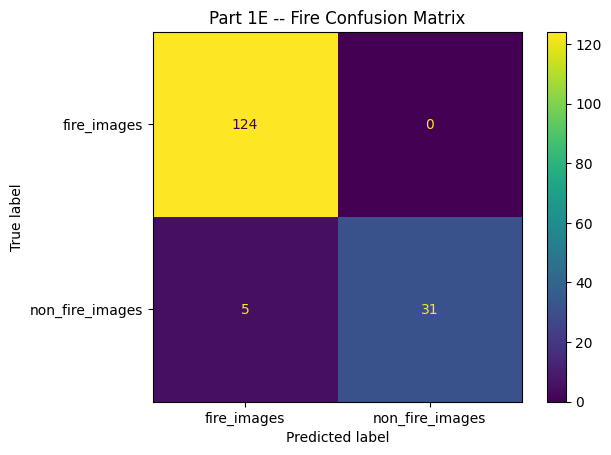

In [29]:
# Build your confusion matrix here

actual_labels = []
final_preds = []

for images, labels in test_fire:
    final_probs = model_fire.predict(images, verbose=0)
    predictions = (final_probs.ravel() >= 0.5).astype(int)

    actual_labels.extend(labels.numpy())
    final_preds.extend(predictions)

# Create the confusion matrix
final_cm = confusion_matrix(actual_labels, final_preds)

ConfusionMatrixDisplay(
    final_cm,
    display_labels=class_names_fire
).plot()

plt.title("Part 1E -- Fire Confusion Matrix")
plt.show()

*Your answer:*  A false negative is more costly because missing a real fire could put people in danger. My model missed 0 fires but produced 5 false alarms. I would consider raising the non-fire cutoff above 0.5 to catch more fires, even if it causes more false alarms.

---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [30]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

replace eurosat_data/EuroSAT_RGB/Forest/Forest_864.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 
error:  invalid response [{ENTER}]
replace eurosat_data/EuroSAT_RGB/Forest/Forest_864.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [31]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [32]:
# Preprocess the data here

def preprocess_mobilenet(image, label):
    return preprocess_input(image), label

train_sat = train_raw_sat.map(preprocess_mobilenet)
val_sat = val_raw_sat.map(preprocess_mobilenet)
test_sat = test_raw_sat.map(preprocess_mobilenet)

In [33]:
# Build your model here

base_sat = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_sat.trainable = False

x = base_sat.output
x = GlobalAveragePooling2D()(x)
output = Dense(len(class_names_sat), activation='softmax')(x)

model_sat = Model(inputs=base_sat.input, outputs=output)

In [34]:
# Compile your model here

model_sat.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_sat.summary()

## 2C — Train and Evaluate

In [ ]:
# Train your model here

history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=5
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1085s 2s/step - accuracy: 0.8821 - loss: 0.3625 - val_accuracy: 0.9321 - val_loss: 0.2173
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1092s 2s/step - accuracy: 0.9339 - loss: 0.1927 - val_accuracy: 0.9403 - val_loss: 0.1893
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1128s 2s/step - accuracy: 0.9481 - loss: 0.1572 - val_accuracy: 0.9393 - val_loss: 0.1831
Epoch 4/10
327/591 ━━━━━━━━━━━━━━━━━━━━ 7:38 2s/step - accuracy: 0.9496 - loss: 0.1429

In [ ]:
# Report validation and test accuracy here

val_loss_sat, val_accuracy_sat = model_sat.evaluate(val_sat)
test_loss_sat, test_accuracy_sat = model_sat.evaluate(test_sat)

print("Satellite Validation Accuracy:", val_accuracy_sat)
print("Satellite Test Accuracy:", test_accuracy_sat)

## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

In [ ]:
# Build your confusion matrix here

actual_labels_sat = []
final_preds_sat = []

for images, labels in test_sat:
    final_probs_sat = model_sat.predict(images, verbose=0)
    predictions = np.argmax(final_probs_sat, axis=1)

    actual_labels_sat.extend(labels.numpy())
    final_preds_sat.extend(predictions)

# Create the confusion matrix
final_cm_sat = confusion_matrix(actual_labels_sat, final_preds_sat)

ConfusionMatrixDisplay(
    final_cm_sat,
    display_labels=class_names_sat
).plot(xticks_rotation=90)

plt.title("Part 2D -- Satellite Confusion Matrix")
plt.show()

*Your answer:*




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |0.971| |
| Test Accuracy |0.975| |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.